# Beginner — Bank Marketing: GridSearchCV, RandomizedSearchCV, Nested CV

## Dataset Validation
Run this cell to verify that your datasets are present and correctly formatted.

In [ ]:
# --- DATASET VALIDATION ---
import os
import pandas as pd

def validate_dataset(filepath, expected_columns=None, avoid_columns=None):
    if not os.path.exists(filepath):
        print(f'❌ ERROR: Dataset not found at {filepath}')
        return False
    try:
        df = pd.read_csv(filepath, nrows=5)
        print(f'✅ SUCCESS: Dataset found at {filepath} (Columns: {df.shape[1]})')
        if expected_columns:
            missing = [c for c in expected_columns if c not in df.columns]
            if missing:
                print(f'⚠️ WARNING: Missing expected columns: {missing}')
                return False
        if avoid_columns:
            forbidden = [c for c in avoid_columns if c in df.columns]
            if forbidden:
                print(f'❌ ERROR: Found forbidden columns {forbidden}. Wrong dataset!')
                return False
        return True
    except Exception as e:
        print(f'❌ ERROR: Could not read dataset: {e}')
        return False

print('Validating Santander Dataset...')
validate_dataset('../data/train.csv', expected_columns=['target', 'var_0'], avoid_columns=['Survived', 'PassengerId'])

,level,method,dataset,target,best_score,runtime_seconds,best_params
0,beginner,GridSearchCV,bank.csv,y,0.895156,4.976412,"{'clf__max_depth': None, 'clf__n_estimators': ..."
1,beginner,RandomizedSearchCV,bank.csv,y,0.895156,1.660346,"{'clf__n_estimators': 200, 'clf__max_depth': N..."


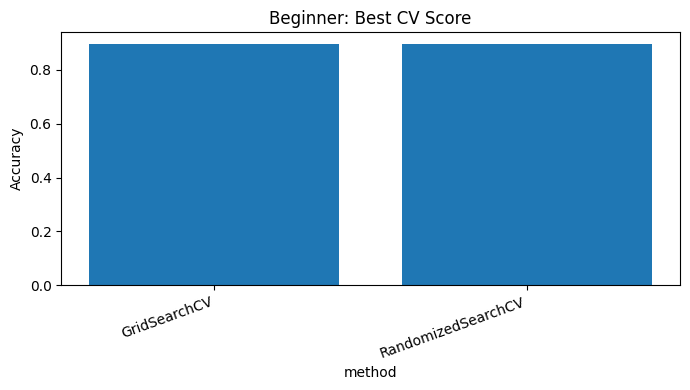

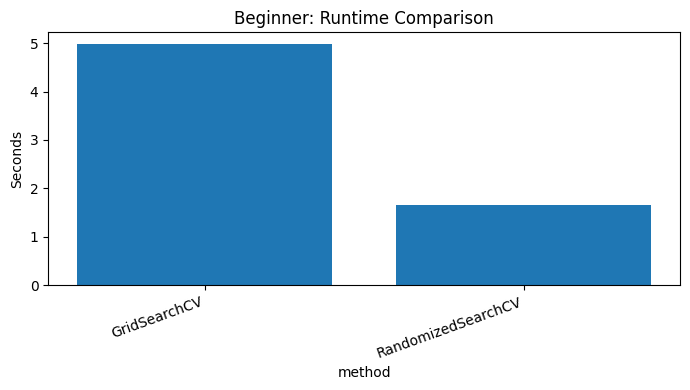

In [1]:

from pathlib import Path
import time
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, StratifiedKFold, cross_validate
from scipy.stats import randint, loguniform

RANDOM_STATE = 42
PROJECT_ROOT = Path.cwd().parents[0] if Path.cwd().name == "notebooks" else Path.cwd()
DATA_DIR = PROJECT_ROOT / "data"
OUT_TABLES = PROJECT_ROOT / "output" / "tables"
OUT_FIGURES = PROJECT_ROOT / "output" / "figures"
OUT_SUBMISSIONS = PROJECT_ROOT / "output" / "submissions"
for p in [OUT_TABLES, OUT_FIGURES, OUT_SUBMISSIONS]:
    p.mkdir(parents=True, exist_ok=True)

def make_encoder():
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)

def load_bank_data():
    candidates = [DATA_DIR / "bank.csv", DATA_DIR / "bank-full.csv", DATA_DIR / "bank-additional-full.csv"]
    path = next((p for p in candidates if p.exists()), None)
    if path is None:
        raise FileNotFoundError("No Bank Marketing file found. Expected bank.csv in ../data.")
    df = pd.read_csv(path, sep=None, engine="python")
    possible_targets = ["y", "deposit", "target", "subscribed"]
    target_col = next((c for c in possible_targets if c in df.columns), df.columns[-1])
    y_raw = df[target_col].astype(str).str.strip().str.lower().str.replace('"', '', regex=False)
    mapping = {"yes": 1, "no": 0, "y": 1, "n": 0, "true": 1, "false": 0, "1": 1, "0": 0}
    y = y_raw.map(mapping)
    if y.isna().any():
        classes = sorted(y_raw.dropna().unique())
        if len(classes) != 2:
            raise ValueError(f"Target column {target_col} must be binary. Found {classes}")
        y = y_raw.map({classes[0]: 0, classes[1]: 1})
    X = df.drop(columns=[target_col])
    return X, y.astype(int), path.name, target_col

def bank_preprocessor(X):
    categorical = X.select_dtypes(include=["object", "category"]).columns.tolist()
    numeric = X.select_dtypes(exclude=["object", "category"]).columns.tolist()
    return ColumnTransformer([
        ("cat", make_encoder(), categorical),
        ("num", "passthrough", numeric),
    ])

def save_bar_chart(df, x_col, y_col, title, path, ylabel=None):
    plt.figure(figsize=(7, 4))
    plt.bar(df[x_col].astype(str), df[y_col])
    plt.title(title)
    plt.xlabel(x_col)
    plt.ylabel(ylabel or y_col)
    plt.xticks(rotation=20, ha="right")
    plt.tight_layout()
    plt.savefig(path, dpi=160)
    plt.show()

X, y, source, target_col = load_bank_data()
preprocess = bank_preprocessor(X)
pipe = Pipeline([
    ("preprocess", preprocess),
    ("clf", RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1)),
])

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
param_grid = {
    "clf__n_estimators": [50, 100, 200],
    "clf__max_depth": [3, 5, None],
}

start = time.time()
grid = GridSearchCV(pipe, param_grid, cv=cv, scoring="accuracy", n_jobs=-1)
grid.fit(X, y)
grid_runtime = time.time() - start

start = time.time()
random_search = RandomizedSearchCV(
    pipe,
    param_distributions=param_grid,
    n_iter=10,
    cv=cv,
    scoring="accuracy",
    n_jobs=-1,
    random_state=RANDOM_STATE,
)
random_search.fit(X, y)
random_runtime = time.time() - start

beginner_results = pd.DataFrame([
    {"level": "beginner", "method": "GridSearchCV", "dataset": source, "target": target_col, "best_score": grid.best_score_, "runtime_seconds": grid_runtime, "best_params": str(grid.best_params_)},
    {"level": "beginner", "method": "RandomizedSearchCV", "dataset": source, "target": target_col, "best_score": random_search.best_score_, "runtime_seconds": random_runtime, "best_params": str(random_search.best_params_)},
])
beginner_results.to_csv(OUT_TABLES / "01_beginner_grid_random_results.csv", index=False)
display(beginner_results)

save_bar_chart(beginner_results, "method", "best_score", "Beginner: Best CV Score", OUT_FIGURES / "01_beginner_score_comparison.png", "Accuracy")
save_bar_chart(beginner_results, "method", "runtime_seconds", "Beginner: Runtime Comparison", OUT_FIGURES / "02_beginner_runtime_comparison.png", "Seconds")


## Nested Cross-Validation

In [2]:

outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
inner_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

nested_search = GridSearchCV(pipe, param_grid, cv=inner_cv, scoring="accuracy", n_jobs=-1)
nested_scores = cross_validate(nested_search, X, y, cv=outer_cv, scoring="accuracy", return_train_score=False, n_jobs=-1)

nested_folds = pd.DataFrame({"fold": np.arange(1, len(nested_scores["test_score"]) + 1), "test_score": nested_scores["test_score"]})
nested_folds.to_csv(OUT_TABLES / "02_beginner_nested_cv_folds.csv", index=False)

nested_summary = pd.DataFrame([{
    "level": "beginner",
    "method": "Nested Cross-Validation",
    "dataset": source,
    "mean_accuracy": nested_scores["test_score"].mean(),
    "std_accuracy": nested_scores["test_score"].std(),
    "n_outer_folds": len(nested_scores["test_score"]),
}])
nested_summary.to_csv(OUT_TABLES / "03_beginner_nested_cv_summary.csv", index=False)
display(nested_folds)
display(nested_summary)


,fold,test_score
0,1,0.903867
1,2,0.888274
2,3,0.903761
3,4,0.903761
4,5,0.893805


,level,method,dataset,mean_accuracy,std_accuracy,n_outer_folds
0,beginner,Nested Cross-Validation,bank.csv,0.898694,0.00649,5
